In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(0)

We define our models: both an NN and a PeNN

In [2]:
class PhysicalParameters:
    kb: float = 1.38064852e-23  # [m2 kg s-2 K-1]
    Na: float = 6.02214179e23  # [mol−1]
    T: float = 293.0  # [K]

In [3]:

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(2, 8)
        self.relu1 = nn.ReLU()
        self.hidden = nn.Linear(8, 8)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        
        x = self.input(x)
        x = self.relu1(x)
        x = self.hidden(x)
        x = self.relu2(x)
        x = self.output(x)

        return x


In [4]:
class SLayer(nn.Module):
    """Physics-encoded layer for the structural parameter S.

    Uses a Quemada-style relation in log10-space:
    theta = 10**(log10(gamma_dot) - log10_gamma_c)
    S = (S0 + theta * S_inf) / (1 + theta)

    log10_gamma_c is trainable and corresponds physically to the
    characteristic shear rate gamma_c.
    """

    def __init__(self, S0: float = 1.0, S_inf: float = 0.0,
                 a: float = 5.0e-9,  # [m]
                 eta_f: float = 1.0e-3,  # [Pa s]
                 T: float = 293.0,  # [K]
                 kB: float = 1.380649e-23):  # [m^2 kg s^-2 K^-1]
        super().__init__()

        self.S0 = S0
        self.S_inf = S_inf

        # Initial guess for gamma_c from physical parameters
        gamma_c_phys = (kB * T) / (6.0 * np.pi * eta_f * (a ** 3))
        log10_gamma_c_init = np.log10(gamma_c_phys)

        # Trainable log10(gamma_c)
        self.log10_gamma_c = nn.Parameter(
            torch.tensor([log10_gamma_c_init], dtype=torch.float32)
        )

    def forward(self, log10_gamma_dot: torch.Tensor) -> torch.Tensor:
        """Compute S from log10(gamma_dot).

        log10_gamma_dot: shape (N, 1)
        returns S with shape (N, 1)
        """
        # theta = gamma_dot / gamma_c in log10-space
        log10_theta = log10_gamma_dot - self.log10_gamma_c
        theta = torch.pow(10.0, log10_theta)

        S = (self.S0 + theta * self.S_inf) / (1.0 + theta)
        return S


In [5]:
class PhiELayer(nn.Module):
    """Physics-encoded layer for effective volume fraction phi_e.

    Relation: phi_e = phi_p * (1 + C * S)
    C is trainable and corresponds to the compactness factor (1/varphi - 1).
    """

    def __init__(self, C_init: float = 2.0):
        super().__init__()
        self.C = nn.Parameter(torch.tensor([C_init], dtype=torch.float32))

    def forward(self, phi_p: torch.Tensor, S: torch.Tensor) -> torch.Tensor:
        """Compute phi_e from phi_p and S.

        phi_p, S: shape (N, 1)
        returns phi_e with shape (N, 1)
        """
        phi_e = phi_p * (1.0 + self.C * S)
        return phi_e

In [6]:
class EtaLayer(nn.Module):
    """Physics-encoded layer for viscosity.

    Relation in Quemada model:
    eta = eta_f * (1 - phi_e / phi_m)^(-2)

    We work in log10-space and make 1/phi_m and log10(eta_f) trainable.
    """

    def __init__(self, phi_m_init: float = 0.63, eta_f_init: float = 1.0e-3):
        super().__init__()
        # Trainable 1 / phi_m
        self.inv_phi_m = nn.Parameter(
            torch.tensor([1.0 / phi_m_init], dtype=torch.float32)
        )
        # Trainable log10(eta_f)
        self.log10_eta_f = nn.Parameter(
            torch.tensor([np.log10(eta_f_init)], dtype=torch.float32)
        )

    def forward(self, phi_e: torch.Tensor) -> torch.Tensor:
        """Compute log10(eta) from phi_e.

        phi_e: shape (N, 1)
        returns log10(eta) with shape (N, 1)
        """
        one_minus = 1.0 - phi_e * self.inv_phi_m
        # Numerical safety: clamp away from zero
        one_minus = torch.clamp(one_minus, min=1e-6)

        # eta = eta_f * (1 - phi_e / phi_m)^(-2)
        log10_eta = self.log10_eta_f - 2.0 * torch.log10(one_minus)
        return log10_eta

In [7]:
class PeNN(nn.Module):
    """Simple physics-encoded Quemada network.

    Inputs:  [log10_gamma_dot, phi_p]
    Output:  log10_eta

    S-layer uses log10_gamma_dot and fixed S0, S_inf.
    PhiE-layer combines phi_p and S.
    Eta-layer maps phi_e to log10(eta).
    """

    def __init__(self,
                 S0: float = 1.0,
                 S_inf: float = 0.0,
                 a: float = 5.0e-9,
                 eta_f: float = 1.0e-3,
                 T: float = 293.0,
                 phi_m_init: float = 0.63,
                 C_init: float = 2.0):
        super().__init__()

        self.S_layer = SLayer(S0=S0, S_inf=S_inf, a=a, eta_f=eta_f, T=T)
        self.phi_e_layer = PhiELayer(C_init=C_init)
        self.eta_layer = EtaLayer(phi_m_init=phi_m_init, eta_f_init=eta_f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (N, 2) with columns [log10_gamma_dot, phi_p]."""
        log10_gamma_dot = x[:, 0:1]
        phi_p = x[:, 1:2]

        S = self.S_layer(log10_gamma_dot)
        phi_e = self.phi_e_layer(phi_p, S)
        log10_eta = self.eta_layer(phi_e)
        return log10_eta


In the next section we generate artificial data

In [8]:
def gen_Quemada_data(input_vars, target_var, N_data_points,
                     phi_p_min=0.01, phi_p_max=0.2,
                     log10_gamma_min=-5.0, log10_gamma_max=3.0,
                     S0=1.0, S_inf=0.0,
                     C=2.0, eta_f=1.0e-3,
                     a=5.0e-9, T=293.0,
                     phi_m=0.63,
                     kB=1.380649e-23):
    """Generate synthetic Quemada viscosity data.

    Returns a DataFrame with the requested input and target columns plus
    helper columns log10_gamma_dot and log10_eta.
    """

    column_names = input_vars + target_var + ["log10_gamma_dot", "log10_eta"]
    df_gen = pd.DataFrame(columns=column_names)

    # Sample random phi_p and log10(gamma_dot)
    phi_p = np.random.uniform(phi_p_min, phi_p_max, size=N_data_points)
    log10_gamma = np.random.uniform(log10_gamma_min, log10_gamma_max, size=N_data_points)
    gamma_dot = 10 ** log10_gamma

    # Compute Pe (theta)
    Pe = (6.0 * np.pi * eta_f * (a ** 3) * gamma_dot) / (kB * T)

    # Structure parameter S
    S = (S0 + Pe * S_inf) / (1.0 + Pe)

    # Effective volume fraction
    phi_e = phi_p * (1.0 + C * S)

    # Viscosity (Quemada)
    eta = eta_f * (1.0 - (phi_e / phi_m)) ** (-2.0)

    log10_eta = np.log10(eta)

    df_gen["gamma_dot"] = gamma_dot
    df_gen["phi_p"] = phi_p
    df_gen["S0"] = S0
    df_gen["Sinf"] = S_inf
    df_gen["C"] = C
    df_gen["eta_f"] = eta_f
    df_gen["a"] = a
    df_gen["T"] = T
    df_gen["viscosity"] = eta
    df_gen["log10_gamma_dot"] = log10_gamma
    df_gen["log10_eta"] = log10_eta

    return df_gen


In [9]:
input_vars = ["gamma_dot", "phi_p", "S0", "Sinf", "C", "eta_f", "a", "T"]
target_var = ["viscosity"]

# Define constants
kb = 1.380649e-23  # Boltzmann constant, unit: m2 kg s-2 K-1

# Generate a dataset
df = gen_Quemada_data(input_vars, target_var, N_data_points=5000)
print(df.head())

   gamma_dot     phi_p   S0  Sinf    C  eta_f             a      T  viscosity  \
0  38.638945  0.015420  1.0   0.0  2.0  0.001  5.000000e-09  293.0   0.001165   
1   0.000160  0.144895  1.0   0.0  2.0  0.001  5.000000e-09  293.0   0.010404   
2   3.619304  0.171342  1.0   0.0  2.0  0.001  5.000000e-09  293.0   0.029509   
3  34.894310  0.069547  1.0   0.0  2.0  0.001  5.000000e-09  293.0   0.002235   
4   0.000095  0.125744  1.0   0.0  2.0  0.001  5.000000e-09  293.0   0.006212   

   log10_gamma_dot  log10_eta  
0         1.587025  -2.933757  
1        -3.796189  -1.982791  
2         0.558625  -1.530049  
3         1.542755  -2.650628  
4        -4.022329  -2.206760  


Now, we are ready to train and test the NN and PeNN

In [10]:
# Prepare data for training: inputs are [log10_gamma_dot, phi_p], target is log10_eta

X = df[["log10_gamma_dot", "phi_p"]].values.astype(np.float32)
y = df["log10_eta"].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# Instantiate models
nn_model = NeuralNet()
penn_model = PeNN()

# Loss and optimizers
criterion = nn.MSELoss()
nn_optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3)
penn_optimizer = torch.optim.Adam(penn_model.parameters(), lr=1e-3)

# Training loop
n_epochs = 500

nn_train_losses = []
nn_test_losses = []
penn_train_losses = []
penn_test_losses = []

for epoch in range(n_epochs):
    # ---- Train NN ----
    nn_model.train()
    nn_optimizer.zero_grad()
    nn_pred = nn_model(X_train_t)
    nn_loss = criterion(nn_pred, y_train_t)
    nn_loss.backward()
    nn_optimizer.step()

    # Evaluate on test
    nn_model.eval()
    with torch.no_grad():
        nn_test_pred = nn_model(X_test_t)
        nn_test_loss = criterion(nn_test_pred, y_test_t)

    nn_train_losses.append(nn_loss.item())
    nn_test_losses.append(nn_test_loss.item())

    # ---- Train PeNN ----
    penn_model.train()
    penn_optimizer.zero_grad()
    penn_pred = penn_model(X_train_t)
    penn_loss = criterion(penn_pred, y_train_t)
    penn_loss.backward()
    penn_optimizer.step()

    # Evaluate on test
    penn_model.eval()
    with torch.no_grad():
        penn_test_pred = penn_model(X_test_t)
        penn_test_loss = criterion(penn_test_pred, y_test_t)

    penn_train_losses.append(penn_loss.item())
    penn_test_losses.append(penn_test_loss.item())

# Final evaluation metrics
nn_model.eval()
penn_model.eval()
with torch.no_grad():
    nn_y_pred = nn_model(X_test_t).numpy().flatten()
    penn_y_pred = penn_model(X_test_t).numpy().flatten()

nn_mse = mean_squared_error(y_test.flatten(), nn_y_pred)
nn_r2 = r2_score(y_test.flatten(), nn_y_pred)
penn_mse = mean_squared_error(y_test.flatten(), penn_y_pred)
penn_r2 = r2_score(y_test.flatten(), penn_y_pred)

print(f"NN   - MSE: {nn_mse:.3e}, R^2: {nn_r2:.4f}")
print(f"PeNN - MSE: {penn_mse:.3e}, R^2: {penn_r2:.4f}")

NN   - MSE: 4.157e-01, R^2: -0.0479
PeNN - MSE: 5.169e-14, R^2: 1.0000


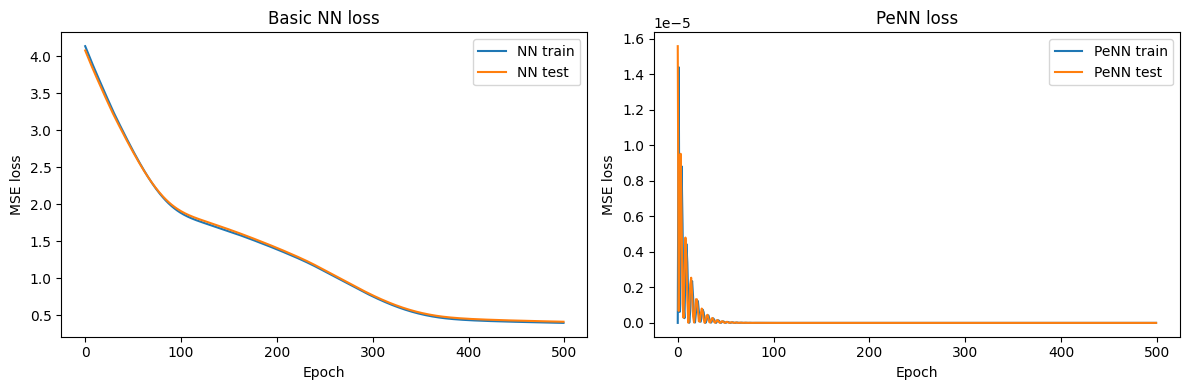

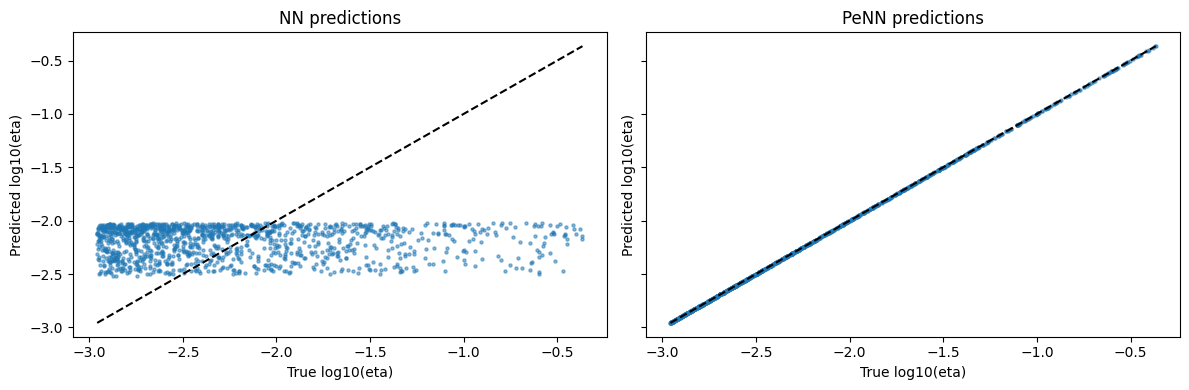

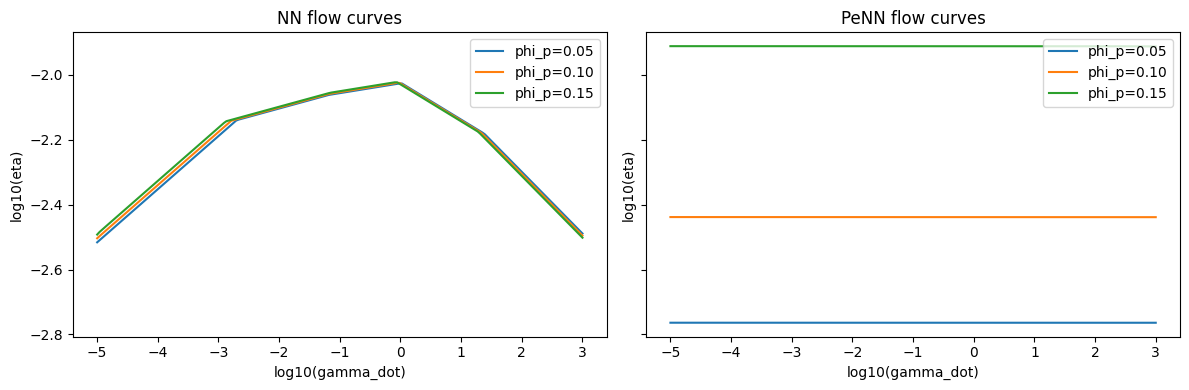

In [11]:
# Plot loss curves for NN and PeNN

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(nn_train_losses, label="NN train")
axes[0].plot(nn_test_losses, label="NN test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Basic NN loss")
axes[0].legend()

axes[1].plot(penn_train_losses, label="PeNN train")
axes[1].plot(penn_test_losses, label="PeNN test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss")
axes[1].set_title("PeNN loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Scatter plots: predicted vs true log10(eta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].scatter(y_test, nn_y_pred, s=5, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0].set_xlabel("True log10(eta)")
axes[0].set_ylabel("Predicted log10(eta)")
axes[0].set_title("NN predictions")

axes[1].scatter(y_test, penn_y_pred, s=5, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[1].set_xlabel("True log10(eta)")
axes[1].set_ylabel("Predicted log10(eta)")
axes[1].set_title("PeNN predictions")

plt.tight_layout()
plt.show()

# Example flow curves for a few phi_p values (interpolation/extrapolation illustration)

phi_samples = [0.05, 0.10, 0.15]
log10_gamma_grid = np.linspace(-5, 3, 200, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for phi in phi_samples:
    X_grid = np.column_stack([
        log10_gamma_grid,
        np.full_like(log10_gamma_grid, phi)
    ]).astype(np.float32)

    X_grid_t = torch.from_numpy(X_grid)

    with torch.no_grad():
        nn_log10_eta = nn_model(X_grid_t).numpy().flatten()
        penn_log10_eta = penn_model(X_grid_t).numpy().flatten()

    axes[0].plot(log10_gamma_grid, nn_log10_eta, label=f"phi_p={phi:.2f}")
    axes[1].plot(log10_gamma_grid, penn_log10_eta, label=f"phi_p={phi:.2f}")

axes[0].set_xlabel("log10(gamma_dot)")
axes[0].set_ylabel("log10(eta)")
axes[0].set_title("NN flow curves")
axes[0].legend()

axes[1].set_xlabel("log10(gamma_dot)")
axes[1].set_ylabel("log10(eta)")
axes[1].set_title("PeNN flow curves")
axes[1].legend()

plt.tight_layout()
plt.show()

Finally, we visualize and save the final results

In [13]:
# Ways to add physics:
# Generate artificial data using physical models, for training NNs
# Adding physical information regarding symmetries that need to be obeyed.
# Incorporating physical information to allow a model to better estimate its errors: comparing predictions to a physical rule that needs to be obeyed when calculating the loss function.
# Adding physical information to nodes in the network


In [ ]:
# Metrics:
# Calculate and visualize: MSE, R^2 (Coefficient of determination = Pearson's r squared), Friedman test with p-value
# How well do the investigated models capture interpolation and extrapolation?